In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

def generate_states(env,model,steps):
    states = []
    
    # Reset environment to get initial state
    state = env.reset()
    
    with torch.no_grad():
        for i in range(steps):   
            
            action, _ = model.model.predict(state, deterministic=True)
            next_state, _, done, _ = env.step(action)

            states.append(state)
            
            # Move to the next state
            state = next_state
            
            # Reset environment if the episode is done
            if done:
                state = env.reset()
        
    # Convert lists to numpy arrays for consistent data handling
    return np.array(states), len(state)

# SHAP method

import shap

def get_actions(model,state):
    action, _ = model.model.predict(state, deterministic=True)
    return action

def feature_importance_shap(env,model,steps,feature_names):
    '''
    The shap method requires a deterministic model. 
    SHAP value focuses on feature’s short-term on the actions and ignore the long term impact on the rewards.
    There might be extra plots without a name due to extra states generated during the process, you can just ignore it.
    '''
    
    # Generate states
    states, len_of_state = generate_states(env,model,steps)
    
    # Calculate Shapley value
    explainer = shap.KernelExplainer(lambda state: get_actions(model,state), states)
    shap_values = explainer.shap_values(states)

    # Reshape the value to plot
    l, w, _ = shap_values.shape
    shap_values = shap_values.reshape(l,w)
    feature_num = len(feature_names)
    
    # Name the features
    if feature_num < len_of_state:
        feature_names += [' '] * (len_of_state - feature_num)

    # Visualize the result
    shap.summary_plot(shap_values,feature_names)
    
    return pd.DataFrame(shap_values,columns=feature_names)

/Users/yyf/Desktop/pythonProject/blockhouse_ml/equities/sell/utils/data_handler.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.data['mid_price'] = (self.data['high'] + self.data['low']) / 2
/Users/yyf/Desktop/pythonProject/blockhouse_ml/equities/sell/utils/data_handler.py:65: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  self.data["mean_vol"] = self.data['mid_price'].pct_change().rolling(window=window_size).mean()
/Users/yyf/Desktop/pythonProject/blockhouse_ml/equities/sell/utils/data_handler.py:65: SettingWithCopyWarning: 
A value is tryin

Training from scratch...
--------------------------------------------------
Penalty per trade: -0.016848572834793494
Actions:2
Number of steps:2
Remaining inventory: 0
Day End: False
--------------------------------------------------
Penalty per trade: -0.34563225864738656
Actions:2
Number of steps:2
Remaining inventory: 0
Day End: False
--------------------------------------------------
Penalty per trade: -0.075180915919519
Actions:1
Number of steps:1
Remaining inventory: 0
Day End: False
--------------------------------------------------
Penalty per trade: -0.1085563522580191
Actions:2
Number of steps:2
Remaining inventory: 0
Day End: False
--------------------------------------------------
Penalty per trade: -0.03863563717756702
Actions:1
Number of steps:1
Remaining inventory: 0
Day End: False
--------------------------------------------------
Penalty per trade: -0.18749398659259595
Actions:2
Number of steps:2
Remaining inventory: 0
Day End: False
-----------------------------------

Using 500 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


--------------------------------------------------
Penalty per trade: -0.256110940822757
Actions:2
Number of steps:2
Remaining inventory: 0
Day End: False
--------------------------------------------------
Penalty per trade: -0.2293390507910119
Actions:1
Number of steps:1
Remaining inventory: 0
Day End: False
--------------------------------------------------
Penalty per trade: -0.2695158703105185
Actions:1
Number of steps:1
Remaining inventory: 0
Day End: False
--------------------------------------------------
Penalty per trade: -0.11496500252161722
Actions:2
Number of steps:2
Remaining inventory: 0
Day End: False
--------------------------------------------------
Penalty per trade: -0.06731162746015396
Actions:2
Number of steps:2
Remaining inventory: 0
Day End: False
--------------------------------------------------
Penalty per trade: -0.04119047574308732
Actions:1
Number of steps:1
Remaining inventory: 0
Day End: False
--------------------------------------------------
Penalty per

  0%|          | 0/500 [00:00<?, ?it/s]

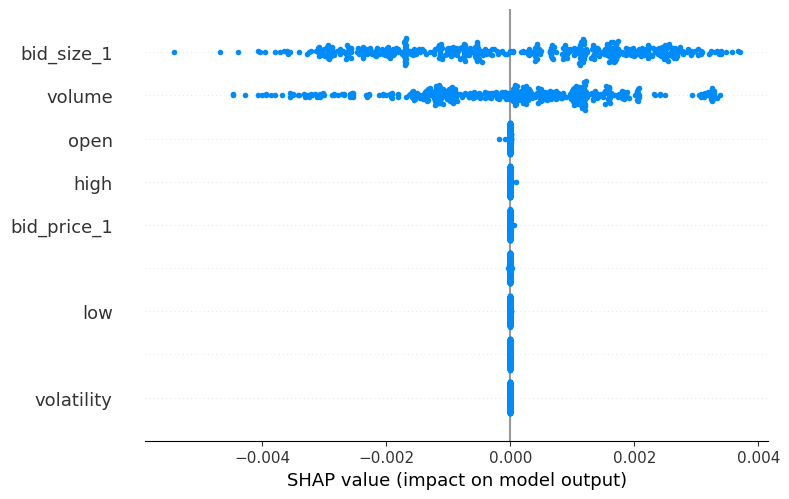

In [104]:
# Test
from GordonRitter.utils.bet_sizing_model_utils import BetSizingModel
from GordonRitter.utils.bet_sizing_env import TradingEnvironment

df = pd.read_csv('merged_bid_ask_ohlcv_data.csv')
df = df.iloc[20:]

optm_pts_per_day=20
train_split = (int(df.shape[0]*0.8)//optm_pts_per_day)*optm_pts_per_day
df_train = df.iloc[:train_split]
df_test = df.iloc[train_split:]
state_columns = ['bid_price_1','bid_size_1','high','low','open','volume','volatility']

env_train = TradingEnvironment(
    data=df_train,
    reset_count=optm_pts_per_day,
    initial_inventory=10000,
    state_columns=state_columns
)

model = BetSizingModel(name='model', env=env_train, overide=True, model_dir='Models/bet_sizing_v1')

env_test = TradingEnvironment(
    data=df_train,
    reset_count=optm_pts_per_day,
    initial_inventory=10000,
    state_columns=state_columns
)

shap_value = feature_importance_shap(env_test,model,500,state_columns)